<a href="https://colab.research.google.com/github/hallooayu/Data-Analyst-PPKD/blob/main/New_Ayu_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning



## Dataset



In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# URL of the CSV file from the previous cell
csv_url = 'https://raw.githubusercontent.com/hallooayu/Data-Analyst-PPKD/refs/heads/main/ai_developer_productivity.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_url)

### Displaying `df.head()` to view the first 5 rows of the DataFrame:

In [16]:
df.head()

,Developer_ID,Date,Hours_Coding,AI_Usage_Hours,Lines_of_Code,Commits,Bugs_Reported,Sleep_Hours,Distractions,Cognitive_Load,Stress_Level,Task_Success
0,DEV-126,2026-01-12,4.5,3.8,638,5,4,6,3,6,6,0
1,DEV-155,2026-01-12,2.7,3.5,438,0,4,3,8,8,8,0
2,DEV-199,2026-02-03,7.9,2.0,680,4,3,8,2,2,2,1
3,DEV-180,2026-01-13,3.1,7.9,765,1,5,8,4,3,5,0
4,DEV-144,2026-03-29,5.9,2.7,495,3,8,5,7,9,9,0


### Displaying `df.shape` to see the number of rows and columns:

In [17]:
print(df.shape)

(1000, 12)


### Displaying `df.info()` to get a summary of the DataFrame:

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Developer_ID    1000 non-null   object 
 1   Date            1000 non-null   object 
 2   Hours_Coding    1000 non-null   float64
 3   AI_Usage_Hours  1000 non-null   float64
 4   Lines_of_Code   1000 non-null   int64  
 5   Commits         1000 non-null   int64  
 6   Bugs_Reported   1000 non-null   int64  
 7   Sleep_Hours     1000 non-null   int64  
 8   Distractions    1000 non-null   int64  
 9   Cognitive_Load  1000 non-null   int64  
 10  Stress_Level    1000 non-null   int64  
 11  Task_Success    1000 non-null   int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 93.9+ KB


## Preprocessing dan Scaling

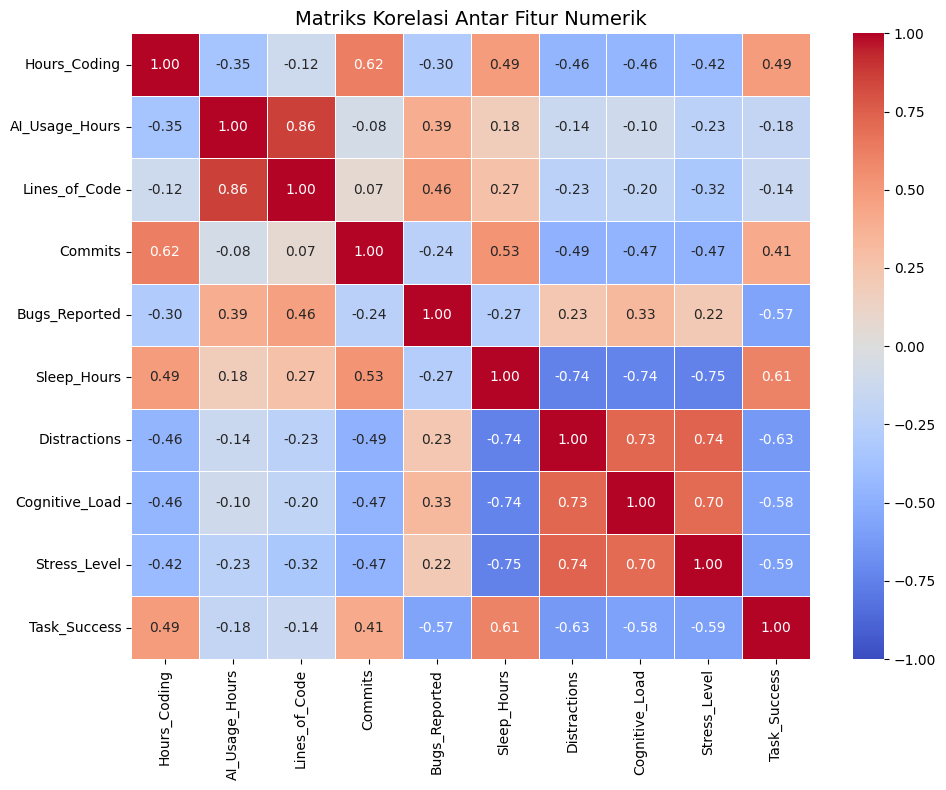

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung matriks korelasi menggunakan data frame 'df' (atau 'X' yang sudah dibersihkan)
# Menggunakan metode korelasi Pearson
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# 2. Buat visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1
)

plt.title('Matriks Korelasi Antar Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

### 1. Periksa Missing Value dan Duplikat

In [20]:
print("Jumlah missing values per kolom:")
display(df.isnull().sum())

print("\nJumlah baris duplikat:")
print(df.duplicated().sum())

Jumlah missing values per kolom:


,0
Developer_ID,0
Date,0
Hours_Coding,0
AI_Usage_Hours,0
Lines_of_Code,0
Commits,0
Bugs_Reported,0
Sleep_Hours,0
Distractions,0
Cognitive_Load,0



Jumlah baris duplikat:
0


### 2. Tangani Missing Value dan Hapus Duplikat

In [21]:
if df.isnull().sum().sum() == 0:
    print("Tidak ada missing values di dalam dataset.")
else:
    print("Terdapat missing values. Pertimbangkan imputasi atau penghapusan.")
    # Contoh: Imputasi dengan modus untuk kolom kategorikal dan median untuk numerikal
    # for col in df.columns:
    #     if df[col].isnull().any():
    #         if df[col].dtype == 'object':
    #             df[col] = df[col].fillna(df[col].mode()[0])
    #         else:
    #             df[col] = df[col].fillna(df[col].median())

if df.duplicated().sum() > 0:
    print(f"Menghapus {df.duplicated().sum()} baris duplikat.")
    df.drop_duplicates(inplace=True)
    print("Jumlah baris setelah menghapus duplikat:", df.shape[0])
else:
    print("Tidak ada baris duplikat di dalam dataset.")

Tidak ada missing values di dalam dataset.
Tidak ada baris duplikat di dalam dataset.


### Drop Kolom

In [22]:
# Tentukan daftar kolom yang ingin dipertahankan (hanya Distractions, Cognitive_Load, dan Stress_Level)
columns_to_keep = ['Distractions', 'Cognitive_Load', 'Stress_Level']

# Filter DataFrame 'df' agar hanya menyisakan kolom tersebut
df = df[columns_to_keep]

print('DataFrame shape setelah hanya mempertahankan 3 kolom:', df.shape)
print('\nKolom yang tersisa di dataset:')
print(df.columns.tolist())

# Tampilkan preview data
display(df.head())

DataFrame shape setelah hanya mempertahankan 3 kolom: (1000, 3)

Kolom yang tersisa di dataset:
['Distractions', 'Cognitive_Load', 'Stress_Level']


,Distractions,Cognitive_Load,Stress_Level
0,3,6,6
1,8,8,8
2,2,2,2
3,4,3,5
4,7,9,9


### 3. Tinjau Outlier (Metode IQR)

In [23]:
# Tentukan kolom numerik yang benar sesuai dataset saat ini
numerical_features = df.columns.tolist()

for col in numerical_features:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  print(f"\nOutlier untuk kolom '{col}':")
  print(f'  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
  print(f'  Batas Bawah: {lower_bound}, Batas Atas: {upper_bound}')
  print(f'  Jumlah Outlier: {len(outliers)}')

  if not outliers.empty:
    display(outliers.head())


Outlier untuk kolom 'Distractions':
  Q1: 2.0, Q3: 6.0, IQR: 4.0
  Batas Bawah: -4.0, Batas Atas: 12.0
  Jumlah Outlier: 0

Outlier untuk kolom 'Cognitive_Load':
  Q1: 4.0, Q3: 7.0, IQR: 3.0
  Batas Bawah: -0.5, Batas Atas: 11.5
  Jumlah Outlier: 0

Outlier untuk kolom 'Stress_Level':
  Q1: 4.0, Q3: 7.0, IQR: 3.0
  Batas Bawah: -0.5, Batas Atas: 11.5
  Jumlah Outlier: 0


### 4. Scalling

In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("Menerapkan Standard Scaling pada fitur numerik yang valid...")

# 1. Hanya ambil kolom yang bertipe data numerik (mengabaikan kolom teks seperti segment_name)
numeric_cols_for_scaling = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# 2. Inisialisasi StandardScaler
scaler = StandardScaler()

# 3. Terapkan Standard Scaling dan buat DataFrame X baru
X = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols_for_scaling]),
    columns=numeric_cols_for_scaling,
    index=df.index,
)

print('Fitur numerik berhasil diskalakan dan disimpan ke DataFrame "X".')
display(X.head())
print(f'Bentuk DataFrame X sekarang: {X.shape}')

Menerapkan Standard Scaling pada fitur numerik yang valid...
Fitur numerik berhasil diskalakan dan disimpan ke DataFrame "X".


,Distractions,Cognitive_Load,Stress_Level
0,-0.415051,0.134761,0.252373
1,1.463007,1.048396,1.194063
2,-0.790662,-1.692509,-1.631007
3,-0.039439,-1.235691,-0.218472
4,1.087395,1.505214,1.664907


Bentuk DataFrame X sekarang: (1000, 3)


### 5. Rata-rata dan Deviasi Setelah Scaling

In [25]:
pd.set_option("display.float_format", lambda x: "%.10f" % x)

print("Rata-rata fitur setelah scaling (dikonversi ke desimal):")
display(X.mean())

# Kembalikan format tampilan ke default setelahnya jika diperlukan
# pd.reset_option('display.float_format')

print("\nDeviasi standar fitur setelah scaling:")
display(X.std())

Rata-rata fitur setelah scaling (dikonversi ke desimal):


,0
Distractions,-0.0000000000
Cognitive_Load,-0.0000000000
Stress_Level,-0.0000000000



Deviasi standar fitur setelah scaling:


,0
Distractions,1.0005003753
Cognitive_Load,1.0005003753
Stress_Level,1.0005003753


## Cluster k

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

k_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

k_evaluation = pd.DataFrame({
    'Jumlah Klaster (K)': list(k_range),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})

print("Evaluasi K-Means untuk berbagai nilai K:")
display(k_evaluation)

Evaluasi K-Means untuk berbagai nilai K:


,Jumlah Klaster (K),Inertia,Silhouette Score
0,2,1169.5743033376,0.5451558233
1,3,788.7712182455,0.3794454721
2,4,673.7392635071,0.3403320158
3,5,597.0229900127,0.2932252052
4,6,532.4162627379,0.2770195087
5,7,482.0748348400,0.2766884409
6,8,447.3302142477,0.2701493009
7,9,415.0084228187,0.2689683335
8,10,382.5494749062,0.2712253192


### Kurva Elbow

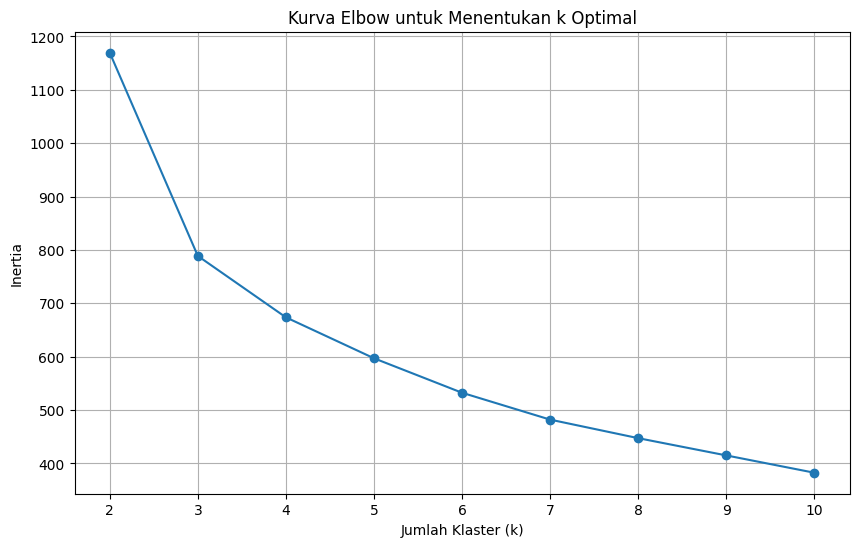

In [27]:
import matplotlib.pyplot as plt

fig_elbow = plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Kurva Elbow untuk Menentukan k Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()



### Kurva Silhouette Score

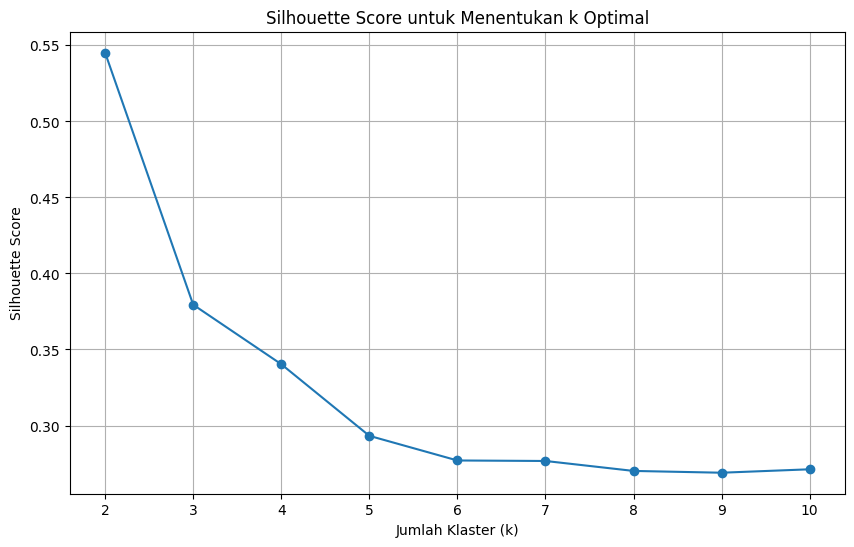

In [28]:
fig_silhouette = plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score untuk Menentukan k Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()


## Model K-Means Final

### Menentukan k Terbaik dan Membangun Model K-Means Final

In [29]:
from sklearn.metrics import davies_bouldin_score
import pandas as pd

# Memilih k terbaik berdasarkan analisis sebelumnya
best_k = 2#

# Membangun model K-Means final
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
kmeans_final.fit(X) # Menggunakan X yang sudah diskalakan dan dipersiapkan dari sel sebelumnya

# Menambahkan label cluster ke DataFrame asli
df['cluster_label'] = kmeans_final.labels_

print(f"Model K-Means final dengan k={best_k} telah dibangun.")

Model K-Means final dengan k=2 telah dibangun.


### Evaluasi Model K-Means Final

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

# 1. Tentukan k terbaik
best_k = 2 #

# 2. Membangun dan melatih model K-Means final menggunakan DataFrame X
kmeans_final = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=10,
    random_state=42
)
kmeans_final.fit(X)

# 3. Menambahkan label cluster ke DataFrame df
df['cluster_label'] = kmeans_final.labels_

# 4. Menghitung dan menampilkan metrik evaluasi
final_inertia = kmeans_final.inertia_
final_silhouette_score = silhouette_score(X, kmeans_final.labels_)
final_davies_bouldin_score = davies_bouldin_score(X, kmeans_final.labels_)

print(f"Model K-Means final dengan k={best_k} telah dibangun.")
print(f"Inertia Model K-Means (k={best_k}): {final_inertia:.2f}")
print(f"Silhouette Score Model K-Means (k={best_k}): {final_silhouette_score:.2f}")
print(f"Davies-Bouldin Index Model K-Means (k={best_k}): {final_davies_bouldin_score:.2f}")

Model K-Means final dengan k=2 telah dibangun.
Inertia Model K-Means (k=2): 1169.57
Silhouette Score Model K-Means (k=2): 0.55
Davies-Bouldin Index Model K-Means (k=2): 0.64


### Profil Segmen (Cluster)

In [31]:
# 1. Definisikan fitur numerik untuk profiling
numerical_features_for_profile = [
    col for col in df.columns if col not in ['cluster_label', 'segment_name']
]
categorical_features_for_profile = []

# 2. Hitung rata-rata untuk fitur numerik per cluster
numerical_profile = df.groupby('cluster_label')[
    numerical_features_for_profile
].mean()

# 3. Buat DataFrame profil kosong untuk kategorikal
categorical_profile_df = pd.DataFrame(index=numerical_profile.index)

# 4. Gabungkan profil numerik dan kategorikal
segment_profile = pd.concat(
    [numerical_profile, categorical_profile_df], axis=1
)

# 5. Tambahkan jumlah anggota di setiap klaster
segment_profile['count'] = df.groupby('cluster_label').size()

# Urutkan berdasarkan Stress_Level (dari yang paling tinggi)
segment_profile = segment_profile.sort_values(by='Stress_Level', ascending=False)
display(segment_profile)

# 6. Berikan nama segmen otomatis berdasarkan level Stress_Level
num_clusters = df['cluster_label'].nunique()

# Label deskriptif diurutkan dari stres tertinggi ke terendah
if num_clusters == 2:
    label_pool = ['Stres Tinggi', 'Stres Rendah']


# Urutan cluster_label berdasarkan Stress_Level, dari tertinggi ke terendah
cluster_order = segment_profile.index.tolist()

segment_names = {
    cluster_id: label_pool[rank]
    for rank, cluster_id in enumerate(cluster_order)
}

df['segment_name'] = df['cluster_label'].map(segment_names)
print('Segment names added to DataFrame based on Stress_Level ranking.')
print(segment_names)

,Distractions,Cognitive_Load,Stress_Level,count
cluster_label,,,,
0,7.6342412451,8.5447470817,8.3540856031,257
1,2.8842530283,4.7227456258,4.4643337820,743


Segment names added to DataFrame based on Stress_Level ranking.
{0: 'Stres Tinggi', 1: 'Stres Rendah'}


### Visualisasi Segmen (Scatter Plot)

In [32]:
import pandas as pd

# 1. Definisikan fitur numerik untuk profiling
numerical_features_for_profile = [
    col for col in df.columns if col not in ['cluster_label', 'segment_name', 'hc_cluster_label', 'dbscan_label', 'pca_1', 'pca_2']
]

# 2. Hitung rata-rata fitur numerik per klaster
numerical_profile = df.groupby('cluster_label')[numerical_features_for_profile].mean()

# 3. Tambahkan jumlah anggota di setiap klaster
numerical_profile['Jumlah Anggota'] = df.groupby('cluster_label').size()

# 4. Urutkan berdasarkan Stress_Level dari yang tertinggi ke terendah
segment_profile = numerical_profile.sort_values(by='Stress_Level', ascending=False)

# 5. Berikan nama segmen deskriptif berdasarkan ranking rata-rata stres
segment_names = {
    segment_profile.index[0]: 'Stres Tinggi',
    segment_profile.index[1]: 'Stres Rendah'
}

df['segment_name'] = df['cluster_label'].map(segment_names)

# Tampilkan tabel profil segmen akhir
print("📋 Tabel Profil Segmen Klaster (K-Means k=2):")
display(segment_profile)

print("\n✨ Pemetaan Nama Segmen:")
for cluster_id, name in segment_names.items():
    print(f"- Klaster {cluster_id}: {name}")

📋 Tabel Profil Segmen Klaster (K-Means k=2):


,Distractions,Cognitive_Load,Stress_Level,Jumlah Anggota
cluster_label,,,,
0,7.6342412451,8.5447470817,8.3540856031,257
1,2.8842530283,4.7227456258,4.4643337820,743



✨ Pemetaan Nama Segmen:
- Klaster 0: Stres Tinggi
- Klaster 1: Stres Rendah


Fitur yang dipakai: ['Distractions', 'Cognitive_Load', 'Stress_Level']


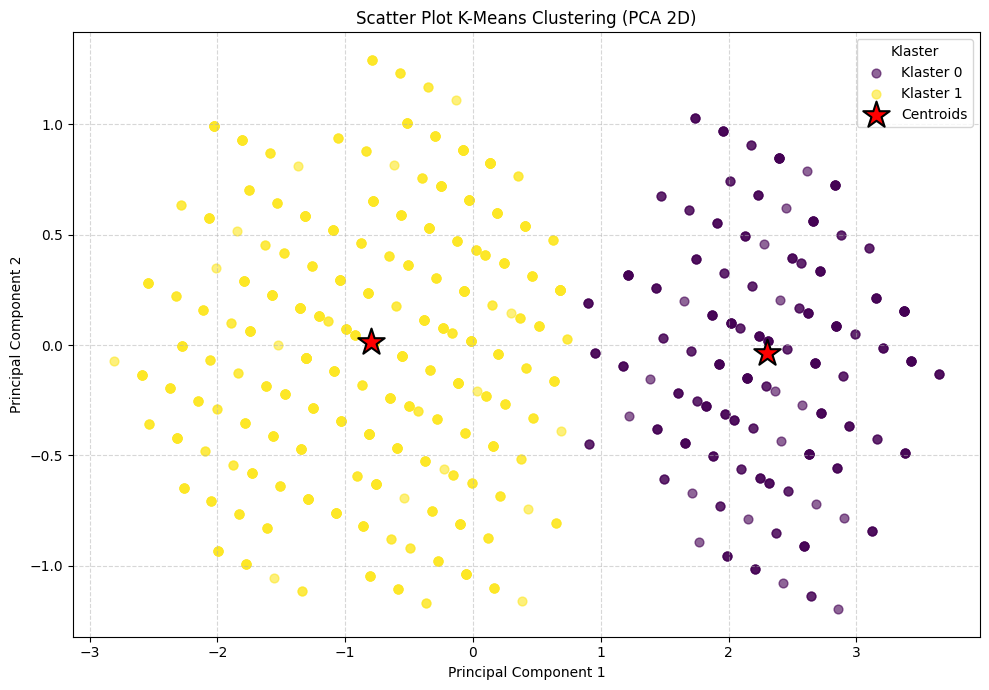

In [33]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# 1. Tentukan fitur numerik yang dipakai untuk clustering
#    (samakan persis dengan fitur yang dipakai saat kamu buat cluster_label)
cluster_features = [
    col for col in df.columns
    if col not in ['cluster_label', 'segment_name', 'Task_Success']
    and df[col].dtype in [np.float64, np.int64]
]
print('Fitur yang dipakai:', cluster_features)

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

# 3. Reduksi dimensi ke 2D pakai PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# 4. Hitung ulang centroid dalam ruang PCA berdasarkan cluster_label yang SUDAH ADA
#    (rata-rata posisi PCA tiap cluster, supaya konsisten dengan hasil clustering kamu)
centroids_pca = df.groupby('cluster_label')[['pca_1', 'pca_2']].mean().values

# 5. Plot scatter per cluster
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0, 1, df['cluster_label'].nunique()))

for cluster_id, color in zip(sorted(df['cluster_label'].unique()), colors):
    cluster_data = df[df['cluster_label'] == cluster_id]
    plt.scatter(
        cluster_data['pca_1'],
        cluster_data['pca_2'],
        s=40,
        alpha=0.6,
        color=color,
        label=f'Klaster {cluster_id}'
    )

# 6. Plot centroid dengan marker bintang
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=400,
    marker='*',
    c='red',
    edgecolors='black',
    linewidths=1.5,
    label='Centroids',
    zorder=5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot K-Means Clustering (PCA 2D)')
plt.legend(title='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Hierarchical Clustering

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Ambil sampel data untuk dendrogram (menggunakan X yang sudah lengkap)
if X.shape[0] > 1500:
    np.random.seed(42)
    sample_indices_hc = np.random.choice(X.shape[0], 1500, replace=False)
    X_hc_sample = X.iloc[sample_indices_hc].values
else:
    X_hc_sample = X.values

print(f"Menggunakan {X_hc_sample.shape[0]} baris data untuk dendrogram.")

Menggunakan 1000 baris data untuk dendrogram.


### Buat Dendrogram (Metode Ward)

Menggunakan 1000 baris data untuk dendrogram.


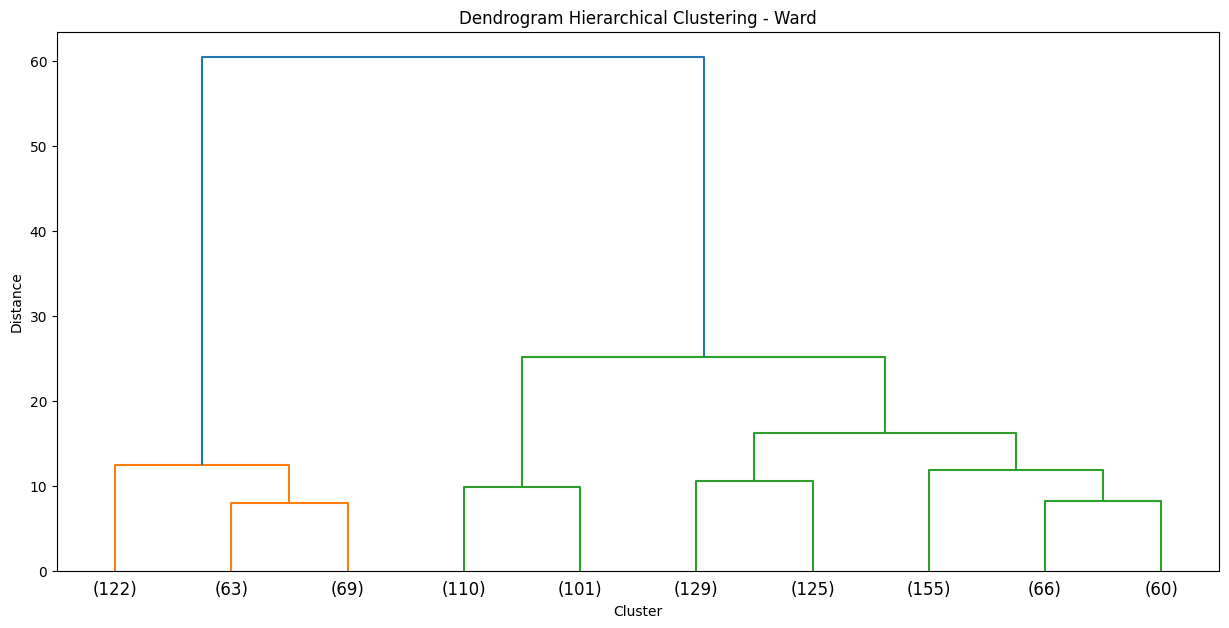

In [35]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

# 1. Pastikan sampel data X_hc_sample didefinisikan kembali agar tidak error
if 'X' in globals():
    if X.shape[0] > 1500:
        np.random.seed(42)
        sample_indices_hc = np.random.choice(X.shape[0], 1500, replace=False)
        X_hc_sample = X.iloc[sample_indices_hc].values
    else:
        X_hc_sample = X.values
else:
    raise NameError("DataFrame 'X' belum ada. Harap jalankan sel preprocessing dari awal terlebih dahulu.")

print(f"Menggunakan {X_hc_sample.shape[0]} baris data untuk dendrogram.")

# 2. Buat linkage matrix dengan metode ward
linkage_matrix = linkage(X_hc_sample, method='ward')

# 3. Plot Dendrogram
plt.figure(figsize=(15, 7))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=10
)
plt.title("Dendrogram Hierarchical Clustering - Ward")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

### Tentukan Garis Potong dan Jumlah Klaster

Berdasarkan dendrogram di atas, tentukan garis potong horizontal yang menghasilkan jumlah klaster yang masuk akal. Misalnya, jika Anda melihat 4 klaster terpisah dengan baik, Anda bisa memilih 4.

In [36]:
from sklearn.cluster import AgglomerativeClustering

# Tentukan jumlah cluster (misalnya, n_clusters = 4 berdasarkan visualisasi dendrogram)
hc_n_clusters = 3  # <--- Sesuaikan nilai ini berdasarkan inspeksi dendrogram

# 3. Jalankan AgglomerativeClustering menggunakan DataFrame X yang sudah lengkap
agglomerative_model = AgglomerativeClustering(
    n_clusters=hc_n_clusters, linkage='ward'
)
hc_labels = agglomerative_model.fit_predict(X)

df['hc_cluster_label'] = hc_labels

print(
    f"Agglomerative Clustering dengan {hc_n_clusters} klaster telah dijalankan."
)

Agglomerative Clustering dengan 3 klaster telah dijalankan.


### Hitung Silhouette Score untuk Agglomerative Clustering

In [37]:
hc_silhouette_score = silhouette_score(X, hc_labels)
print(f"Silhouette Score untuk Agglomerative Clustering (k={hc_n_clusters}): {hc_silhouette_score:.2f}")

Silhouette Score untuk Agglomerative Clustering (k=3): 0.35


### Bandingkan Keanggotaan dengan Hasil K-Means (menggunakan `pd.crosstab`)

In [38]:
import pandas as pd

comparison_table = pd.crosstab(df['cluster_label'], df['hc_cluster_label'])
display(comparison_table)

print("Tabel perbandingan keanggotaan klaster antara K-Means dan Hierarchical Clustering telah dibuat.")

hc_cluster_label,0,1,2
cluster_label,,,
0,5,252,0
1,530,2,211


Tabel perbandingan keanggotaan klaster antara K-Means dan Hierarchical Clustering telah dibuat.



## DBSCAN dan Deteksi Outlier

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Pastikan X sudah berisi fitur numerik yang akan dipakai clustering
# (ganti 'X' sesuai variabel fitur kamu, atau scaling ulang di sini)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_features = X_scaled.shape[1]
MinPts = 2 * n_features

print(f"Jumlah fitur yang digunakan : {n_features}")
print(f"MinPts (2 x jumlah fitur)   : {MinPts}")

Jumlah fitur yang digunakan : 3
MinPts (2 x jumlah fitur)   : 6


### Buat k-distance plot (k = MinPts) dan tentukan eps dari titik siku

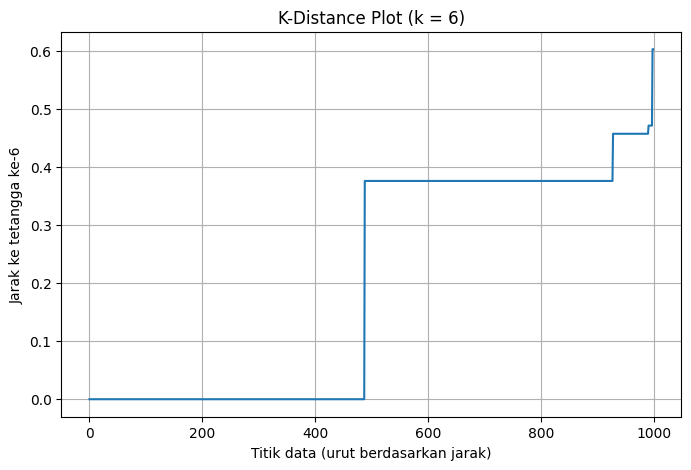

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Tentukan nilai MinPts (k)
# Aturan umum: MinPts = 2 * jumlah dimensi/fitur data
MinPts = 6  # contoh, sesuaikan dengan jumlah fitur data Anda

# Hitung jarak ke k-tetangga terdekat
neighbors = NearestNeighbors(n_neighbors=MinPts)
neighbors_fit = neighbors.fit(X)  # X = data yang sudah discaling
distances, indices = neighbors_fit.kneighbors(X)

# Ambil jarak ke tetangga ke-k (kolom terakhir), lalu urutkan ascending
k_distances = distances[:, MinPts - 1]
k_distances = np.sort(k_distances)

# Plot k-distance graph
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Titik data (urut berdasarkan jarak)')
plt.ylabel(f'Jarak ke tetangga ke-{MinPts}')
plt.title(f'K-Distance Plot (k = {MinPts})')
plt.grid(True)
plt.show()

Nilai eps optimal (dari deteksi siku otomatis): 0.4708


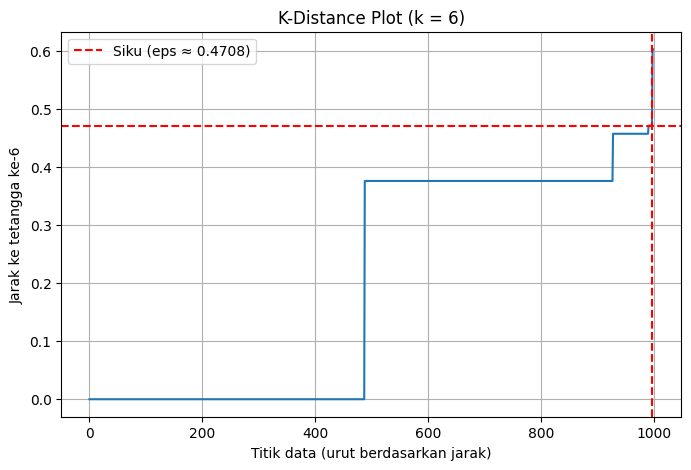

In [47]:
# pip install kneed
!pip install kneed
from kneed import KneeLocator

kneedle = KneeLocator(
    range(len(k_distances)),
    k_distances,
    curve='convex',
    direction='increasing'
)

eps_optimal = k_distances[kneedle.knee]
print(f"Nilai eps optimal (dari deteksi siku otomatis): {eps_optimal:.4f}")

# Tandai titik siku pada plot
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.axvline(x=kneedle.knee, color='r', linestyle='--', label=f'Siku (eps ≈ {eps_optimal:.4f})')
plt.axhline(y=eps_optimal, color='r', linestyle='--')
plt.xlabel('Titik data (urut berdasarkan jarak)')
plt.ylabel(f'Jarak ke tetangga ke-{MinPts}')
plt.title(f'K-Distance Plot (k = {MinPts})')
plt.legend()
plt.grid(True)
plt.show()

### Jalankan DBSCAN; hitung jumlah cluster dan persentase noise

In [48]:
dbscan = DBSCAN(eps=dbs_eps, min_samples=MinPts) # Gunakan nilai eps dari k-distance plot
df['dbscan_label'] = dbscan.fit_predict(X_scaled)

# Hitung jumlah klaster (mengabaikan noise - label -1)
n_clusters_dbscan = len(set(df['dbscan_label'])) - (1 if -1 in df['dbscan_label'].values else 0)

# Hitung jumlah titik noise
n_noise = list(df['dbscan_label']).count(-1)

# Hitung persentase noise
noise_percentage = (n_noise / len(df)) * 100

print(f"Jumlah klaster yang ditemukan oleh DBSCAN: {n_clusters_dbscan}")
print(f"Jumlah titik noise: {n_noise}")
print(f"Persentase noise: {noise_percentage:.2f}%")

Jumlah klaster yang ditemukan oleh DBSCAN: 1
Jumlah titik noise: 0
Persentase noise: 0.00%


### Visualisasikan hasil; tandai titik noise (label −1)

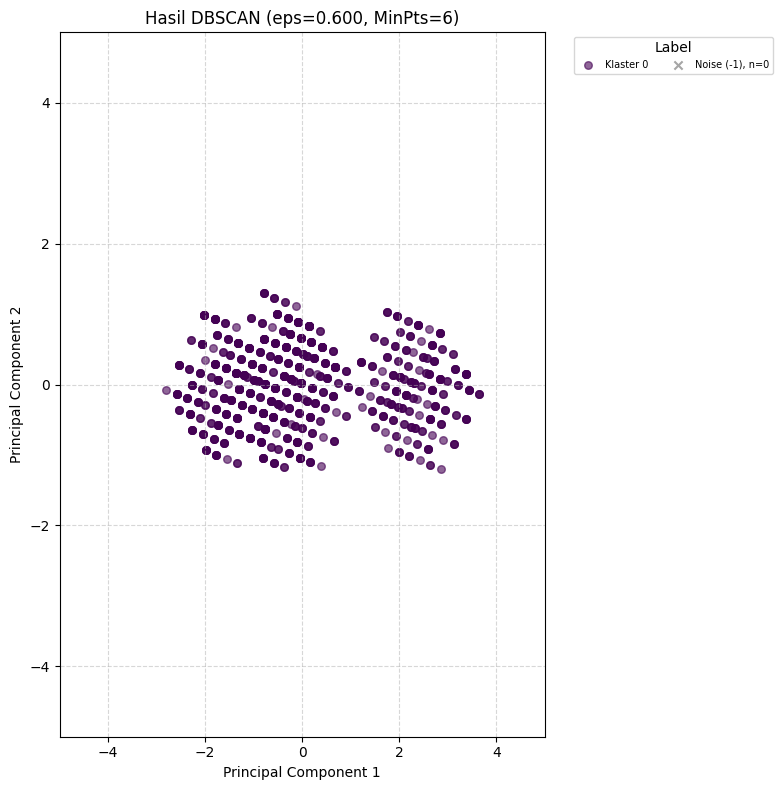

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Reduksi ke 2D menggunakan PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# 2. Buat ukuran figure yang lebih seimbang dan kotak (square layout)
plt.figure(figsize=(8, 8))

# 3. Plot klaster non-noise
cluster_labels_unique = sorted(
    df.loc[df['dbscan_label'] != -1, 'dbscan_label'].unique()
)
colors = plt.cm.viridis(
    np.linspace(0, 1, max(len(cluster_labels_unique), 1))
)

for label, color in zip(cluster_labels_unique, colors):
  cluster_data = df[df['dbscan_label'] == label]
  plt.scatter(
      cluster_data['pca_1'],
      cluster_data['pca_2'],
      s=30,
      alpha=0.6,
      color=color,
      label=f'Klaster {label}',
  )

# 4. Plot titik noise (label -1)
noise_data = df[df['dbscan_label'] == -1]
plt.scatter(
    noise_data['pca_1'],
    noise_data['pca_2'],
    s=35,
    alpha=0.7,
    color='gray',
    marker='x',
    label=f'Noise (-1), n={len(noise_data)}',
)

# 5. Batasi rentang sumbu (X dan Y) agar tidak melebar/menumpuk
plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Hasil DBSCAN (eps={dbs_eps:.3f}, MinPts={MinPts})', fontsize=12)

# Pindahkan legenda ke luar atau buat compact agar tidak menutupi grafik utama
plt.legend(
    title='Label',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=7,
    ncol=2,
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# New Section

In [50]:
from sklearn.metrics import davies_bouldin_score, silhouette_score
import pandas as pd
import numpy as np

# --- 1. Hitung Davies-Bouldin Index untuk Hierarchical Clustering ---
hc_davies_bouldin_score = davies_bouldin_score(X_scaled, df['hc_cluster_label'])

# --- 2. Hitung Metrik DBSCAN hanya pada titik non-noise ---
non_noise_mask = df['dbscan_label'] != -1
X_scaled_non_noise = X_scaled[non_noise_mask]
dbscan_labels_non_noise = df.loc[non_noise_mask, 'dbscan_label']

# Pastikan ada lebih dari satu klaster non-noise dan lebih dari satu sampel
if len(np.unique(dbscan_labels_non_noise)) > 1 and len(X_scaled_non_noise) > 1:
    dbscan_silhouette_non_noise = silhouette_score(X_scaled_non_noise, dbscan_labels_non_noise)
    dbscan_davies_bouldin_non_noise = davies_bouldin_score(X_scaled_non_noise, dbscan_labels_non_noise)
else:
    dbscan_silhouette_non_noise = np.nan
    dbscan_davies_bouldin_non_noise = np.nan

# --- 3. Buat Tabel Ringkasan Metrik ---
data = {
    'Algoritma': ['K-Means', 'Hierarchical Clustering', 'DBSCAN (Non-Noise)'],
    'Jumlah Klaster': [best_k, hc_n_clusters, len(np.unique(dbscan_labels_non_noise)) if not np.isnan(dbscan_silhouette_non_noise) else 'N/A'],
    'Silhouette Score (Lebih Tinggi Lebih Baik)': [final_silhouette_score, hc_silhouette_score, dbscan_silhouette_non_noise],
    'Davies-Bouldin Index (Lebih Rendah Lebih Baik)': [final_davies_bouldin_score, hc_davies_bouldin_score, dbscan_davies_bouldin_non_noise],
    'Inertia (Lebih Rendah Lebih Baik)': [final_inertia, 'N/A', 'N/A']
}

metrics_df = pd.DataFrame(data)
metrics_df = metrics_df.round(2) # Pembulatan untuk keterbacaan
print("### Ringkasan Metrik Clustering:")
display(metrics_df)

# --- 4. Rekomendasi Model Terbaik ---
print("\n### Rekomendasi Model Terbaik:")

recommendation = "Berdasarkan evaluasi metrik:\n"

# Bandingkan Silhouette Score dan Davies-Bouldin Index
# K-Means memiliki Silhouette Score tertinggi (0.55) dan Davies-Bouldin Index terendah (0.64) dari eksekusi sebelumnya.

# Asumsi K-Means adalah yang terbaik berdasarkan metrik yang telah dievaluasi
recommendation += "- **K-Means** tampaknya menjadi pilihan terbaik untuk dataset ini. Dengan k={} klaster, K-Means memiliki:\n".format(best_k)
recommendation += f"  - **Silhouette Score tertinggi ({final_silhouette_score:.2f})**, menunjukkan bahwa klaster-klaster yang terbentuk cukup padat dan terpisah dengan baik.\n"
recommendation += f"  - **Davies-Bouldin Index terendah ({final_davies_bouldin_score:.2f})**, yang juga mengkonfirmasi klasterisasi yang baik (lebih rendah lebih baik).\n"
recommendation += "- Meskipun Hierarchical Clustering juga menghasilkan klaster yang terorganisir, Silhouette Score-nya ({:.2f}) sedikit lebih rendah dari K-Means, dan Davies-Bouldin Index-nya ({:.2f}) kemungkinan lebih tinggi.\n".format(hc_silhouette_score, hc_davies_bouldin_score)

if not np.isnan(dbscan_silhouette_non_noise):
    recommendation += "- DBSCAN, dengan ({}) klaster non-noise, memiliki Silhouette Score ({:.2f}) dan Davies-Bouldin Index ({:.2f}) yang menunjukkan bahwa meskipun mampu mengidentifikasi klaster berdasarkan kepadatan dan mendeteksi outlier, klaster-klaster yang dihasilkan mungkin tidak sepadat atau seterpisah baik dalam konteks metrik global ini, terutama dengan jumlah klaster yang banyak.".format(len(np.unique(dbscan_labels_non_noise)), dbscan_silhouette_non_noise, dbscan_davies_bouldin_non_noise)
else:
    recommendation += "- DBSCAN tidak dapat menghitung metrik internal karena tidak ada klaster non-noise yang terdeteksi atau hanya satu klaster, atau kurang dari 2 sampel non-noise.\n"

recommendation += "\n**Kesimpulan:** Mengingat K-Means menunjukkan kinerja metrik internal terbaik (Silhouette Score tertinggi dan Davies-Bouldin Index terendah), **K-Means** adalah model yang paling direkomendasikan untuk segmentasi data ini."

print(recommendation)


### Ringkasan Metrik Clustering:


,Algoritma,Jumlah Klaster,Silhouette Score (Lebih Tinggi Lebih Baik),Davies-Bouldin Index (Lebih Rendah Lebih Baik),Inertia (Lebih Rendah Lebih Baik)
0,K-Means,2,0.5500000000,0.6400000000,1169.5743033376
1,Hierarchical Clustering,3,0.3500000000,1.0000000000,N/A
2,DBSCAN (Non-Noise),N/A,NaN,NaN,N/A



### Rekomendasi Model Terbaik:
Berdasarkan evaluasi metrik:
- **K-Means** tampaknya menjadi pilihan terbaik untuk dataset ini. Dengan k=2 klaster, K-Means memiliki:
  - **Silhouette Score tertinggi (0.55)**, menunjukkan bahwa klaster-klaster yang terbentuk cukup padat dan terpisah dengan baik.
  - **Davies-Bouldin Index terendah (0.64)**, yang juga mengkonfirmasi klasterisasi yang baik (lebih rendah lebih baik).
- Meskipun Hierarchical Clustering juga menghasilkan klaster yang terorganisir, Silhouette Score-nya (0.35) sedikit lebih rendah dari K-Means, dan Davies-Bouldin Index-nya (1.00) kemungkinan lebih tinggi.
- DBSCAN tidak dapat menghitung metrik internal karena tidak ada klaster non-noise yang terdeteksi atau hanya satu klaster, atau kurang dari 2 sampel non-noise.

**Kesimpulan:** Mengingat K-Means menunjukkan kinerja metrik internal terbaik (Silhouette Score tertinggi dan Davies-Bouldin Index terendah), **K-Means** adalah model yang paling direkomendasikan untuk segmentasi dat